In [ ]:
# =============================================================================
# ACCOUNT 3 (Part 1): Finish DenseNet121_FineTuned
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import os, shutil, time, gc
import numpy as np
import pandas as pd
import json, warnings

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")

DATA_ROOT_DRIVE = "/content/drive/MyDrive/Epic and CSCR hospital Dataset_New"
DATA_ROOT = "/content/dataset"
SAVE_DIR = "/content/drive/MyDrive/Brain_Tumor_Results_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

if not os.path.exists(DATA_ROOT):
    print("Copying dataset to local storage...")
    shutil.copytree(DATA_ROOT_DRIVE, DATA_ROOT)

CLASS_NAMES = sorted([c for c in os.listdir(os.path.join(DATA_ROOT, 'Train')) if os.path.isdir(os.path.join(DATA_ROOT, 'Train', c))])

def load_paths_labels(root, split):
    paths, labels = [], []
    for ci, cn in enumerate(CLASS_NAMES):
        d = os.path.join(root, split, cn)
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                paths.append(os.path.join(d, f))
                labels.append(ci)
    return np.array(paths), np.array(labels)

all_train_paths, all_train_labels = load_paths_labels(DATA_ROOT, 'Train')
test_paths, test_labels = load_paths_labels(DATA_ROOT, 'Test')

def create_dataset(paths, labels, batch_size=32, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(len(paths), seed=42)
    def _parse(path, label):
        img = tf.cast(tf.image.resize(tf.image.decode_image(tf.io.read_file(path), channels=3, expand_animations=False), (224, 224)), tf.float32) / 255.0
        return img, tf.one_hot(label, 4)
    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        return tf.clip_by_value(img, 0.0, 1.0), label
    ds = ds.map(_parse, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_dataset = create_dataset(test_paths, test_labels, augment=False, shuffle=False)

# Build DenseNet121 FineTuned
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

def build_densenet121_ft():
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = True
    for layer in base.layers[:-30]: layer.trainable = False
    inp = layers.Input(shape=(224,224,3))
    x = layers.Lambda(lambda img: tf.keras.applications.densenet.preprocess_input(img * 255.0))(inp)
    x = base(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', name='feat128')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, layers.Dense(4, activation='softmax')(x), name='DenseNet121_FineTuned')

# TRAIN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'cv_account3.json')
all_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_val_metrics, fold_test_preds, fold_test_probs, fold_val_accuracies, fold_times = [], [], [], [], []

print("\n" + "="*70 + "\nTraining: DenseNet121_FineTuned (5-Fold CV)\n" + "="*70)

# Lowered batch size to 16 to prevent memory crashes!
for fi, (tr_idx, va_idx) in enumerate(skf.split(all_train_paths, all_train_labels)):
    print(f"  Fold {fi+1}/5", end=" ... ", flush=True)
    train_ds = create_dataset(all_train_paths[tr_idx], all_train_labels[tr_idx], batch_size=16, augment=True)
    val_ds = create_dataset(all_train_paths[va_idx], all_train_labels[va_idx], batch_size=16, augment=False, shuffle=False)

    tf.keras.backend.clear_session(); gc.collect()
    model = build_densenet121_ft()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=20, verbose=0, callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)])
    dt = time.time() - t0
    fold_times.append(dt)

    val_probs = np.concatenate([model.predict(bi, verbose=0) for bi, _ in val_ds])
    val_true = np.concatenate([np.argmax(bl.numpy(), axis=1) for _, bl in val_ds])
    val_pred = np.argmax(val_probs, axis=1)

    va_acc = accuracy_score(val_true, val_pred)
    fold_val_metrics.append({'accuracy': va_acc, 'f1_score': f1_score(val_true, val_pred, average='weighted'),
                             'precision': precision_score(val_true, val_pred, average='weighted'),
                             'recall': recall_score(val_true, val_pred, average='weighted')})
    fold_val_accuracies.append(va_acc)

    test_probs = np.concatenate([model.predict(bi, verbose=0) for bi, _ in test_dataset])
    test_true = np.concatenate([np.argmax(bl.numpy(), axis=1) for _, bl in test_dataset])
    fold_test_preds.append(np.argmax(test_probs, axis=1).tolist())
    fold_test_probs.append(test_probs.tolist())

    print(f"Val={va_acc:.4f} | Test={accuracy_score(test_true, np.argmax(test_probs, axis=1)):.4f} | {dt:.0f}s")
    del model, train_ds, val_ds; gc.collect()

fdf = pd.DataFrame(fold_val_metrics)
all_results['DenseNet121_FineTuned'] = {
    'fold_val_metrics': fold_val_metrics, 'fold_val_accuracies': fold_val_accuracies,
    'test_predictions': fold_test_preds, 'test_probabilities': fold_test_probs, 'test_true': test_true.tolist(),
    'best_fold': int(np.argmax(fold_val_accuracies)), 'fold_times': fold_times,
    'cv_accuracy_mean': float(fdf['accuracy'].mean()), 'cv_accuracy_std': float(fdf['accuracy'].std()),
    'cv_f1_mean': float(fdf['f1_score'].mean()), 'cv_f1_std': float(fdf['f1_score'].std()),
    'cv_precision_mean': float(fdf['precision'].mean()), 'cv_precision_std': float(fdf['precision'].std()),
    'cv_recall_mean': float(fdf['recall'].mean()), 'cv_recall_std': float(fdf['recall'].std()),
    'mean_time': float(np.mean(fold_times)), 'n_folds': 5
}

with open(CHECKPOINT_PATH, 'w') as f: json.dump(all_results, f, indent=2)
print(f"\nSaved to {CHECKPOINT_PATH}. Ready to Merge!")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Copying dataset to local storage...

Training: DenseNet121_FineTuned (5-Fold CV)
  Fold 1/5 ... Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/densenet/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Val=0.9823 | Test=0.9596 | 614s
  Fold 2/5 ... Val=0.9828 | Test=0.9354 | 462s
  Fold 3/5 ... Val=0.9801 | Test=0.9677 | 684s
  Fold 4/5 ... Val=0.9828 | Test=0.9661 | 699s
  Fold 5/5 ... Val=0.9855 | Test=0.9591 | 720s

Saved to /content/drive/MyDrive/Brain_Tumor_Results_v2/cv_account3.json. Ready to Merge!


In [ ]:
# =============================================================================
# FINAL MERGE SCRIPT: Run on Account 1
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os, json, warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import chi2

warnings.filterwarnings('ignore')

SAVE_DIR = "/content/drive/MyDrive/Brain_Tumor_Results_v2"
acc1_path = os.path.join(SAVE_DIR, 'cv_account1.json')
acc2_path = os.path.join(SAVE_DIR, 'cv_account2.json')
acc3_path = os.path.join(SAVE_DIR, 'cv_account3.json')

# 1. Load all three JSON files
assert os.path.exists(acc1_path), "Missing cv_account1.json! Please check the folder."
assert os.path.exists(acc2_path), "Missing cv_account2.json! Please check the folder."
assert os.path.exists(acc3_path), "Missing cv_account3.json! Please check the folder."

with open(acc1_path, 'r') as f: res1 = json.load(f)
with open(acc2_path, 'r') as f: res2 = json.load(f)
with open(acc3_path, 'r') as f: res3 = json.load(f)

# 2. Merge them
all_results = {}
all_results.update(res1)
all_results.update(res2)
all_results.update(res3)

# 3. Reorder them logically
ordered = ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen',
           'DenseNet121_Frozen', 'ResNet50_FineTuned', 'DenseNet121_FineTuned']
all_results = {k: all_results[k] for k in ordered if k in all_results}

print(f"Merged models: {list(all_results.keys())}")
assert len(all_results) == 7, f"Expected 7 models, got {len(all_results)}! Check your JSON files."

# 4. Save the final merged checkpoint
merged_path = os.path.join(SAVE_DIR, 'cv_checkpoint.json')
with open(merged_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"Merged checkpoint saved to {merged_path}\n")

# 5. Print Output Summaries
print("="*70)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*70)
print(f"{'Model':<28} {'CV Accuracy':>20} {'CV F1-Score':>20}")
print('-'*75)
for mn, r in all_results.items():
    print(f"  {mn:<26} {r['cv_accuracy_mean']:.4f} +/- {r['cv_accuracy_std']:.4f}  "
          f"{r['cv_f1_mean']:.4f} +/- {r['cv_f1_std']:.4f}")

print("\n" + "="*70)
print("TEST SET RESULTS (Best Validation Fold)")
print("="*70)
for mn, r in all_results.items():
    yt = np.array(r['test_true'])
    yp = np.array(r['test_predictions'][r['best_fold']])
    acc = accuracy_score(yt, yp)
    f1 = f1_score(yt, yp, average='weighted')
    print(f"  {mn:<26} Acc={acc:.4f}  F1={f1:.4f}")

# 6. McNemar's Test
print("\n" + "="*70)
print("McNEMAR'S TEST")
print("="*70)
model_names = list(all_results.keys())
yt_ref = np.array(all_results[model_names[0]]['test_true'])
mcnemar_results = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        na, nb_ = model_names[i], model_names[j]
        pa = np.array(all_results[na]['test_predictions'][all_results[na]['best_fold']])
        pb = np.array(all_results[nb_]['test_predictions'][all_results[nb_]['best_fold']])
        corr_a, corr_b = (pa == yt_ref), (pb == yt_ref)
        b = int(np.sum(corr_a & ~corr_b))
        c = int(np.sum(~corr_a & corr_b))
        stat, pval = (0.0, 1.0) if b + c == 0 else ((abs(b - c) - 1)**2 / (b + c), 1 - chi2.cdf((abs(b - c) - 1)**2 / (b + c), 1))
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        mcnemar_results.append({'A': na, 'B': nb_, 'chi2': stat, 'p': pval, 'sig': sig})
        print(f"  {na:<28} vs {nb_:<28} | chi2={stat:7.2f} p={pval:.6f} {sig}")

with open(os.path.join(SAVE_DIR, 'full_results.json'), 'w') as f:
    json.dump({'cv_results': all_results, 'mcnemar': mcnemar_results}, f, indent=2)

print("\n=== READY FOR FIGURES ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Merged models: ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen', 'DenseNet121_Frozen', 'ResNet50_FineTuned', 'DenseNet121_FineTuned']
Merged checkpoint saved to /content/drive/MyDrive/Brain_Tumor_Results_v2/cv_checkpoint.json

FINAL CROSS-VALIDATION RESULTS
Model                                 CV Accuracy          CV F1-Score
---------------------------------------------------------------------------
  CNN                        0.9539 +/- 0.0071  0.9538 +/- 0.0070
  ViT                        0.7849 +/- 0.0192  0.7814 +/- 0.0221
  Hybrid_CNN_ViT             0.7840 +/- 0.0107  0.7795 +/- 0.0119
  ResNet50_Frozen            0.9291 +/- 0.0052  0.9293 +/- 0.0054
  DenseNet121_Frozen         0.9163 +/- 0.0062  0.9162 +/- 0.0065
  ResNet50_FineTuned         0.9820 +/- 0.0048  0.9820 +/- 0.0048
  DenseNet121_FineTuned      0.9827 +/- 0.0019  0.9827 +/- 0.0019

T

Generating Confusion Matrices...


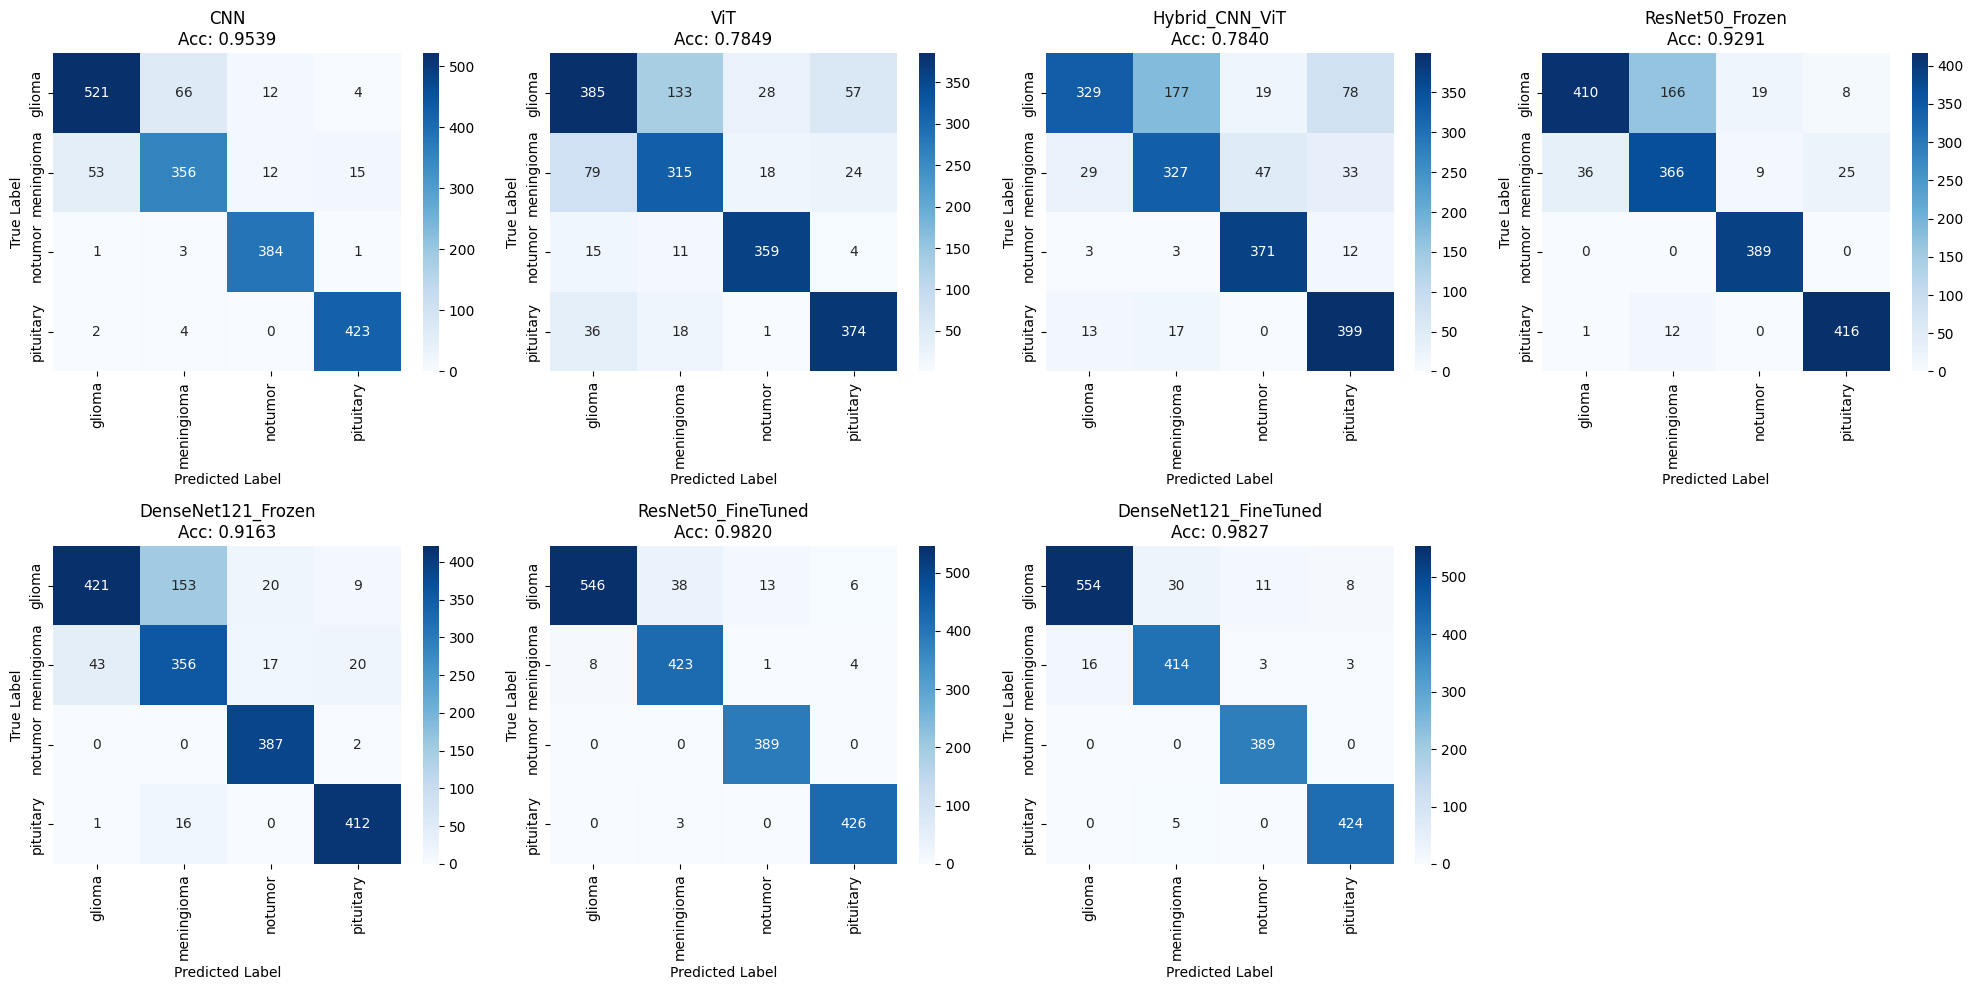

Generating ROC Curves...


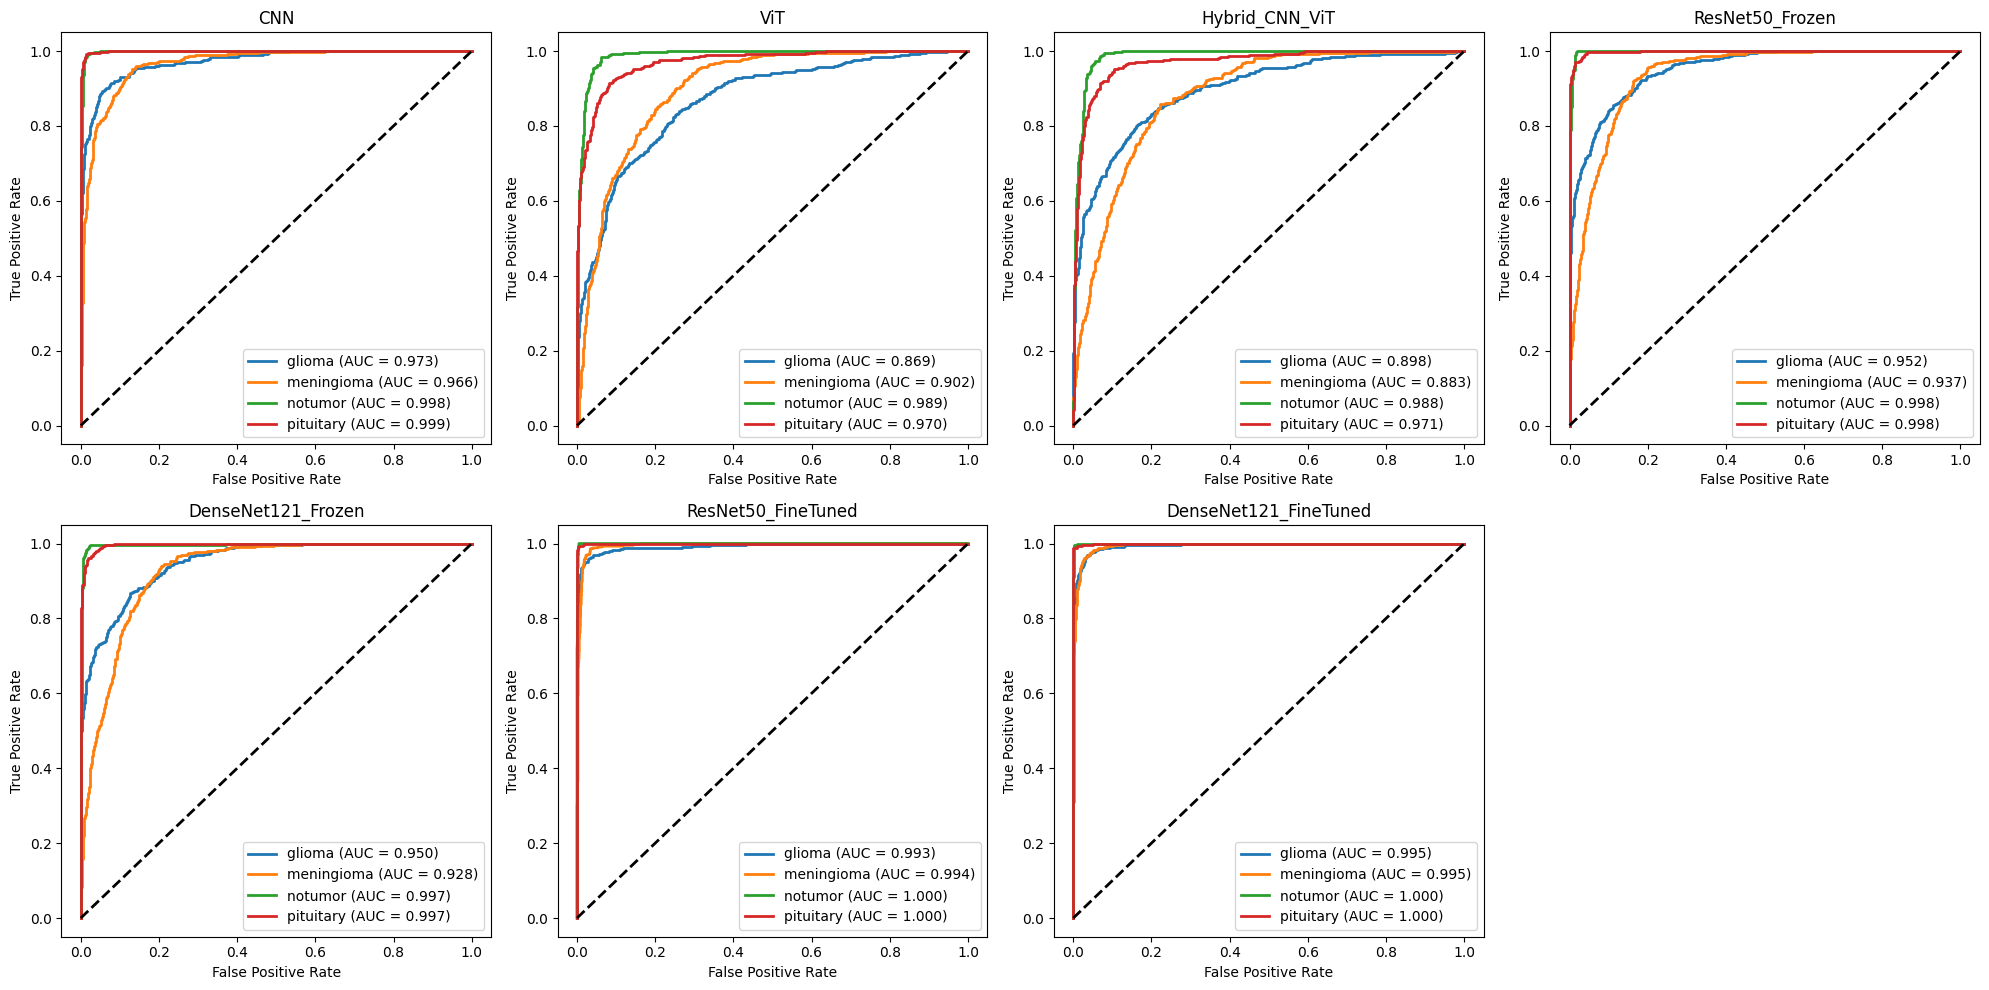

Generating Performance Bars...


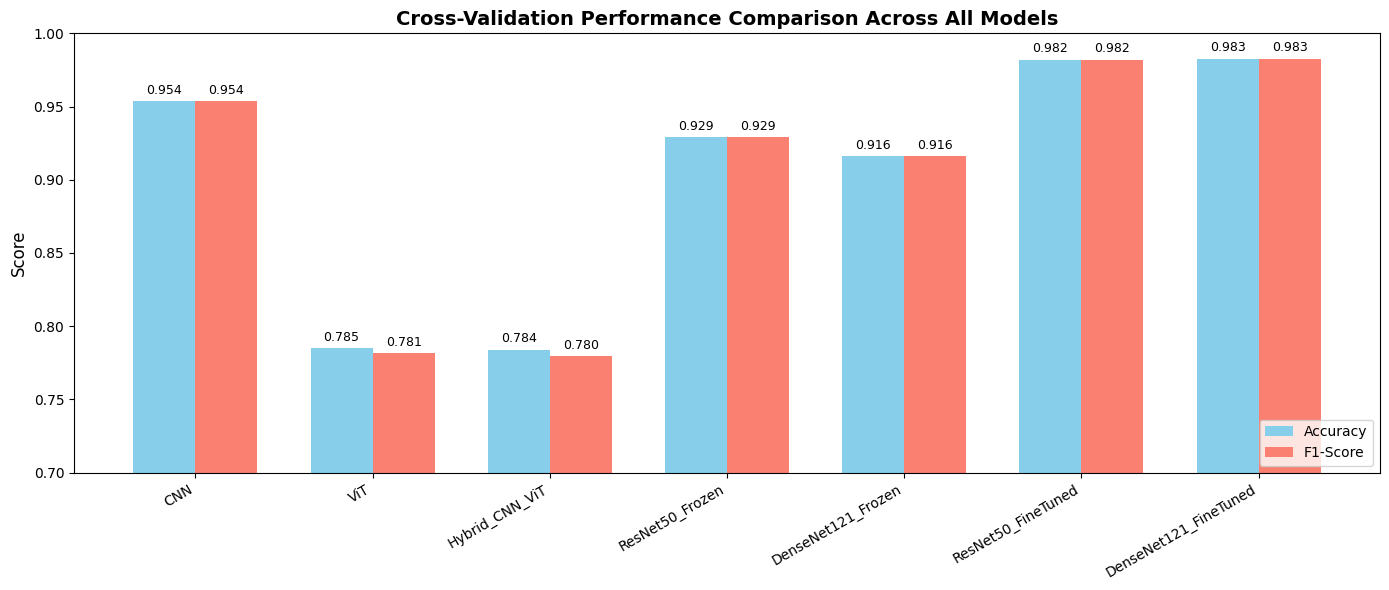

Generating Computational Efficiency Chart...


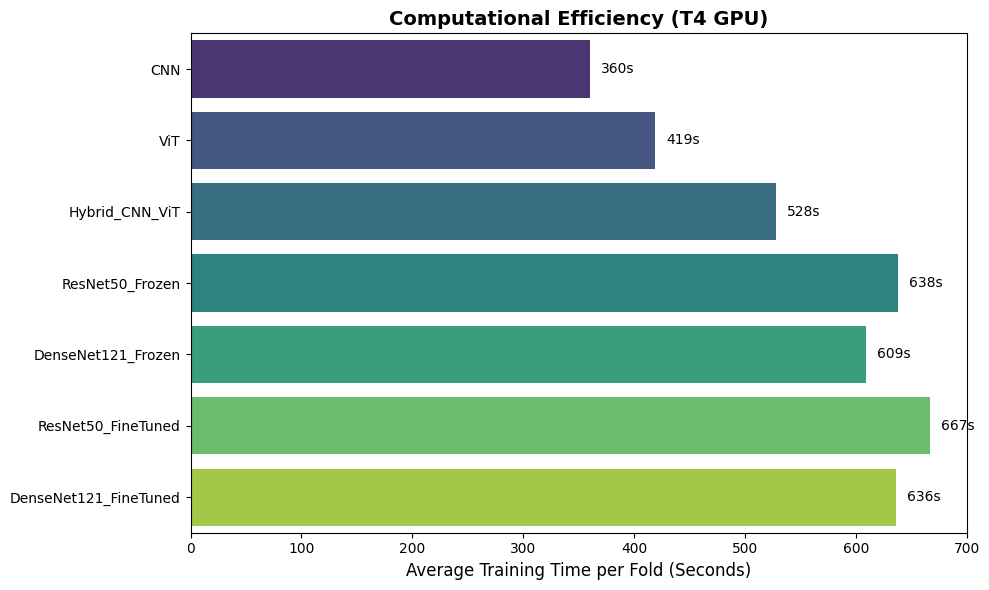


All standard figures have been generated and saved to your Drive!


In [ ]:
# =============================================================================
# FIGURE GENERATION SCRIPT (Runs instantly using merged data)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np
import os

# Ensure save directory exists
SAVE_DIR = "/content/drive/MyDrive/Brain_Tumor_Results_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
ordered_models = ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen',
                  'DenseNet121_Frozen', 'ResNet50_FineTuned', 'DenseNet121_FineTuned']

# -----------------------------------------------------------------------------
# FIGURE 1: Confusion Matrices
# -----------------------------------------------------------------------------
print("Generating Confusion Matrices...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mn in enumerate(ordered_models):
    yt = np.array(all_results[mn]['test_true'])
    yp = np.array(all_results[mn]['test_predictions'][all_results[mn]['best_fold']])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[i].set_title(f"{mn}\nAcc: {all_results[mn]['cv_accuracy_mean']:.4f}")
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

axes[7].axis('off') # Hide the 8th empty subplot
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig1_confusion_matrices.png'), dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# FIGURE 2: ROC Curves
# -----------------------------------------------------------------------------
print("Generating ROC Curves...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mn in enumerate(ordered_models):
    yt = np.array(all_results[mn]['test_true'])
    y_prob = np.array(all_results[mn]['test_probabilities'][all_results[mn]['best_fold']])

    for c in range(4):
        fpr, tpr, _ = roc_curve((yt == c).astype(int), y_prob[:, c])
        roc_auc = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[c]} (AUC = {roc_auc:.3f})')

    axes[i].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[i].set_title(mn)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc="lower right")

axes[7].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig2_roc_curves.png'), dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# FIGURE 3: Performance Comparison Bars
# -----------------------------------------------------------------------------
print("Generating Performance Bars...")
accs = [all_results[mn]['cv_accuracy_mean'] for mn in ordered_models]
f1s = [all_results[mn]['cv_f1_mean'] for mn in ordered_models]

x = np.arange(len(ordered_models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, accs, width, label='Accuracy', color='skyblue')
ax.bar(x + width/2, f1s, width, label='F1-Score', color='salmon')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Validation Performance Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ordered_models, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.0)

for i in range(len(ordered_models)):
    ax.text(x[i] - width/2, accs[i] + 0.005, f"{accs[i]:.3f}", ha='center', fontsize=9)
    ax.text(x[i] + width/2, f1s[i] + 0.005, f"{f1s[i]:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_performance_bars.png'), dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# FIGURE 4: Computational Efficiency
# -----------------------------------------------------------------------------
print("Generating Computational Efficiency Chart...")
times = [all_results[mn]['mean_time'] for mn in ordered_models]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=times, y=ordered_models, palette='viridis', ax=ax)
ax.set_xlabel('Average Training Time per Fold (Seconds)', fontsize=12)
ax.set_title('Computational Efficiency (T4 GPU)', fontsize=14, fontweight='bold')

for i, v in enumerate(times):
    ax.text(v + 10, i, f"{v:.0f}s", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig4_computational_efficiency.png'), dpi=300)
plt.show()
print("\nAll standard figures have been generated and saved to your Drive!")